# Notebook 1 – Analisis Dataset LIN

**Tujuan:** Memahami struktur file LIN dari Bridge Base Online (BBO), menjalankan parser, dan menganalisis statistik dataset secara keseluruhan.

**Output yang dihasilkan:**
- Visualisasi distribusi dataset (`outputs/results/nb01_*.png`)

**Tahap penelitian:** Tahap 1 (Analisis Dataset) & Tahap 2 (Parser LIN)

---
## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

OUT = ROOT / 'outputs' / 'results'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

print(f'ROOT : {ROOT}')
print('Setup selesai.')

ROOT : D:\Bridge-Prediction
Setup selesai.


---
## 1. Struktur File LIN

In [2]:
raw_dir = ROOT / 'data' / 'raw'
lin_files = sorted(raw_dir.glob('*.lin'))

print(f'Jumlah file LIN : {len(lin_files)}')
print(f'\nContoh nama file:')
for f in lin_files[:5]:
    print(f'  {f.name}')
print(f'  ...')
for f in lin_files[-3:]:
    print(f'  {f.name}')

Jumlah file LIN : 411

Contoh nama file:
  85168.lin
  85169.lin
  85170.lin
  85171.lin
  85173.lin
  ...
  TM-86282-1754569906.lin
  TM-90087-1754655837.lin
  TM-90210-1754657957.lin


In [3]:
# Tampilkan isi awal satu file LIN
sample_file = lin_files[-1]   # ambil file TM (format lebih lengkap)
print(f'=== Isi awal: {sample_file.name} ===')
print()
with open(sample_file, encoding='utf-8', errors='replace') as f:
    content = f.read()

# Tampilkan per-token
import re
tokens = re.findall(r'([a-zA-Z]{1,4})\|([^|]*)\|', content)
for tok, val in tokens[:30]:
    val_preview = val[:80] + '...' if len(val) > 80 else val
    print(f'  {tok:4s} | {val_preview}')

=== Isi awal: TM-90210-1754657957.lin ===

  vg   | 90210-1754657957,Team Match,I,1,10,Team1,0,Team2,0
  pg   | 
  pn   | dinandeen,imagi,Filosofi,tabuanlaki,tanah laut,tara58,jorong,cemot
  pg   | 
  rs   | 2HS+1,3SE-2,3NN+1,3NN=,4HE-1,6HE-3,6HE=,2DW+2,2CW+2,3DW+1,1NS=,2HN=,3NS+2,3NS+1,...
  pg   | 
  qx   | o1
  pn   | dinandeen,imagi,Filosofi,tabuanlaki
  st   | 
  md   | 3S2TKH279KD38JC467,S479JH48D57QC5JKA,S6AH36TQD246AC28Q,
  rh   | 
  ah   | Board 1
  sv   | o
  mb   | 1D
  mb   | p
  mb   | 1H
  mb   | p
  mb   | 2H
  mb   | p
  mb   | p
  mb   | p
  pc   | CA
  pc   | C2
  pc   | C9
  pc   | C4
  pg   | 
  pc   | CK
  pc   | C8
  pc   | CT
  pc   | C6


In [4]:
import pandas as pd

token_info = [
    ('vg', 'Event header', 'Nama turnamen, tipe event, skor'),
    ('pn', 'Player names', 'Nama 4 atau 8 pemain'),
    ('rs', 'Results summary', 'Ringkasan kontrak semua board: 4SN+2, 3NW-1, ...'),
    ('qx', 'Board qualifier', 'ID board per meja (o=open, c=closed room)'),
    ('ah', 'Board number', 'Nomor board, mis. "Board 5"'),
    ('md', 'Hand description', 'Dealer + 4 tangan. Format: {dealer}{S hand},{W hand},{N hand},{E hand}'),
    ('sv', 'Vulnerability', 'b=Both, n=NS, e=EW, o/-=None'),
    ('mb', 'Bid', 'Satu bid dalam auction. Tanda ! = alert'),
    ('an', 'Alert/Announce', 'Teks alert untuk bid sebelumnya'),
    ('pc', 'Card played', 'Satu kartu dimainkan, mis. dA, s3, hK'),
    ('mc', 'Claim', 'Jumlah trik yang diklaim oleh declarer'),
    ('pg', 'Page break', 'Separator trik / section (diabaikan parser)'),
]

df_tok = pd.DataFrame(token_info, columns=['Token', 'Nama', 'Deskripsi'])
print('Token LIN yang dikenali parser:')
print(df_tok.to_string(index=False))

Token LIN yang dikenali parser:
Token             Nama                                                              Deskripsi
   vg     Event header                                        Nama turnamen, tipe event, skor
   pn     Player names                                                   Nama 4 atau 8 pemain
   rs  Results summary                       Ringkasan kontrak semua board: 4SN+2, 3NW-1, ...
   qx  Board qualifier                              ID board per meja (o=open, c=closed room)
   ah     Board number                                            Nomor board, mis. "Board 5"
   md Hand description Dealer + 4 tangan. Format: {dealer}{S hand},{W hand},{N hand},{E hand}
   sv    Vulnerability                                           b=Both, n=NS, e=EW, o/-=None
   mb              Bid                                Satu bid dalam auction. Tanda ! = alert
   an   Alert/Announce                                        Teks alert untuk bid sebelumnya
   pc      Card played      

In [5]:
# Contoh decode field md|
sample_md = '3SAQ83HDAT42CKT976,ST9HAQD9653CJ8532,SK754HJ32DKQ87CAQ,'
print('Contoh field md|')
print(f'  Raw   : md|{sample_md}|')
print()

DEALER_MAP = {'1': 'South', '2': 'West', '3': 'North', '4': 'East'}
print(f'  Karakter pertama "{sample_md[0]}" → Dealer: {DEALER_MAP[sample_md[0]]}')
print()

hands_raw = sample_md[1:].split(',')
seat_order = ['South', 'West', 'North', 'East']
for seat, hand_str in zip(seat_order, hands_raw):
    print(f'  {seat:<6}: {hand_str}')

print()
print('  Format per tangan: S{spades}H{hearts}D{diamonds}C{clubs}')
print('  Kartu: A K Q J T 9 8 7 6 5 4 3 2')
print('  Tangan ke-4 (East) sering dikosongkan → diderivasi dari 52 kartu - 3 tangan lain')

Contoh field md|
  Raw   : md|3SAQ83HDAT42CKT976,ST9HAQD9653CJ8532,SK754HJ32DKQ87CAQ,|

  Karakter pertama "3" → Dealer: North

  South : SAQ83HDAT42CKT976
  West  : ST9HAQD9653CJ8532
  North : SK754HJ32DKQ87CAQ
  East  : 

  Format per tangan: S{spades}H{hearts}D{diamonds}C{clubs}
  Kartu: A K Q J T 9 8 7 6 5 4 3 2
  Tangan ke-4 (East) sering dikosongkan → diderivasi dari 52 kartu - 3 tangan lain


---
## 2. Parsing File LIN

In [6]:
from src.parser import LINParser, BoardRecord

parser = LINParser()
boards = parser.parse_directory(raw_dir)

total         = len(boards)
with_contract = sum(1 for b in boards if b.contract_level is not None)
passed_out    = sum(1 for b in boards if b.contract_level is None)
complete_4x13 = sum(
    1 for b in boards
    if len(b.hands) == 4 and all(b.hands[s].total_cards() == 13 for s in 'NSEW')
)

print(f'{'='*45}')
print(f'  Total board di-parse   : {total:>6,}')
print(f'  Board dengan kontrak   : {with_contract:>6,}  ({with_contract/total*100:.1f}%)')
print(f'  Board PASS (tidak bid) : {passed_out:>6,}  ({passed_out/total*100:.1f}%)')
print(f'  Tangan lengkap (4×13)  : {complete_4x13:>6,}  ({complete_4x13/total*100:.1f}%)')
print(f'  Kontrak doubled        : {sum(1 for b in boards if b.doubled):>6,}')
print(f'  Dari {len(lin_files)} file LIN')
print(f'{'='*45}')

  Total board di-parse   :  8,625
  Board dengan kontrak   :  8,602  (99.7%)
  Board PASS (tidak bid) :     23  (0.3%)
  Tangan lengkap (4×13)  :  8,614  (99.9%)
  Kontrak doubled        :    640
  Dari 411 file LIN


In [7]:
# Tampilkan satu board secara detail
sample = next(
    b for b in boards
    if b.contract_level and b.result is not None and len(b.play) >= 10
)

SUIT_SYMBOL = {'S': '♠', 'H': '♥', 'D': '♦', 'C': '♣'}

print(f'Board #{sample.board_number}  |  File: {sample.source_file}  |  Room: {sample.room}')
print(f'Dealer : {sample.dealer}   Vulnerability : {sample.vulnerability}')
print()
print('Distribusi Kartu:')
for seat in ['N', 'E', 'S', 'W']:
    h = sample.hands[seat]
    line = (f'  {seat}:  '
            f'♠ {"-" if not h.spades else " ".join(h.spades):<13}  '
            f'♥ {"-" if not h.hearts else " ".join(h.hearts):<13}  '
            f'♦ {"-" if not h.diamonds else " ".join(h.diamonds):<13}  '
            f'♣ {"-" if not h.clubs else " ".join(h.clubs)}')
    print(line)

print()
print(f'Auction  : {" → ".join(sample.auction)}')
contract = f"{sample.contract_level}{sample.contract_strain}" + ("x" if sample.doubled else "")
result_str = (f"+{sample.result}" if sample.result and sample.result > 0
              else str(sample.result) if sample.result is not None else "?")
print(f'Kontrak  : {contract} oleh {sample.declarer}  →  Made {sample.tricks_made} trik  ({result_str})')
if sample.alerts:
    print(f'Alerts   : {sample.alerts}')

Board #13  |  File: 85168.lin  |  Room: open
Dealer : N   Vulnerability : Both

Distribusi Kartu:
  N:  ♠ K T 8 7        ♥ T 7 6          ♦ 8 7 3          ♣ 7 4 3
  E:  ♠ Q 6 4 2        ♥ J 5 3 2        ♦ 2              ♣ A Q 6 2
  S:  ♠ J 9            ♥ A Q 9          ♦ Q J T 9 6      ♣ J 9 5
  W:  ♠ A 5 3          ♥ K 8 4          ♦ A K 5 4        ♣ K T 8

Auction  : p → p → 1D → 1N → p → 2C → p → 2D → p → 2N → p → 3N → p → p → p
Kontrak  : 3N oleh W  →  Made 8 trik  (-1)


---
## 3. Statistik Dataset

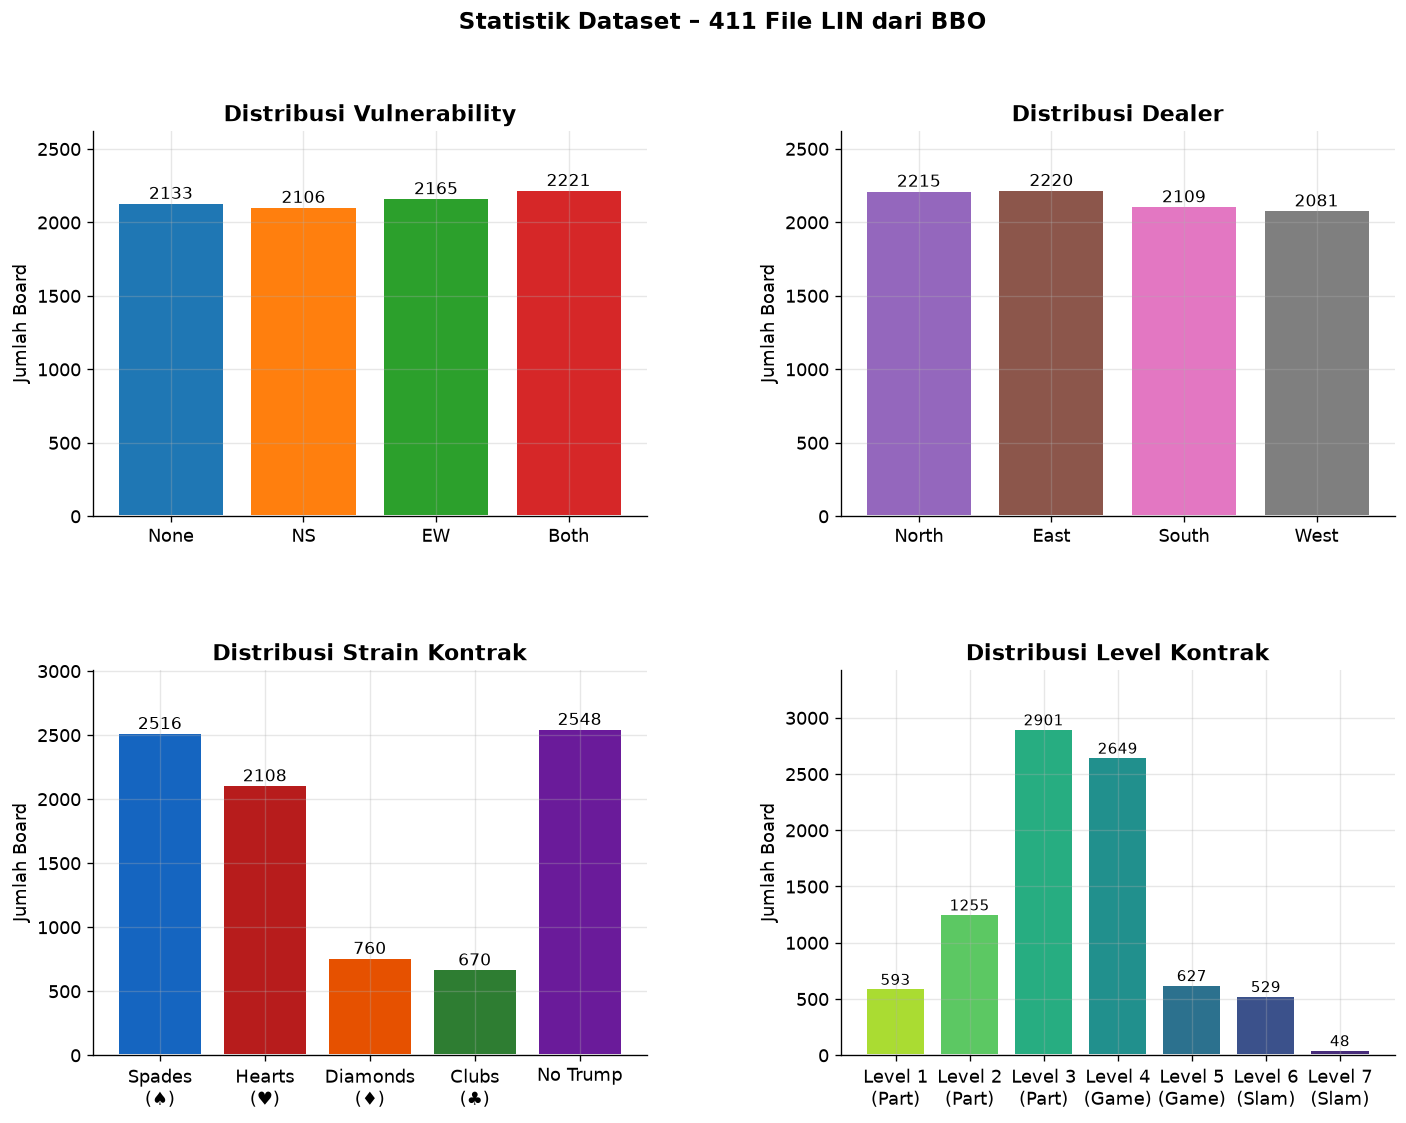

Gambar disimpan.


In [8]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

palette = sns.color_palette('tab10')

# ── Vulnerability ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
vuln_order = ['None', 'NS', 'EW', 'Both']
vuln_cnt   = Counter(b.vulnerability for b in boards)
vvals      = [vuln_cnt.get(v, 0) for v in vuln_order]
bars = ax1.bar(vuln_order, vvals, color=palette[:4], edgecolor='white', linewidth=1.2)
ax1.bar_label(bars, fmt='%d', fontsize=10)
ax1.set_title('Distribusi Vulnerability', fontweight='bold')
ax1.set_ylabel('Jumlah Board')
ax1.set_ylim(0, max(vvals) * 1.18)

# ── Dealer ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
dealer_cnt = Counter(b.dealer for b in boards)
dvals      = [dealer_cnt.get(s, 0) for s in ['N', 'E', 'S', 'W']]
bars = ax2.bar(['North', 'East', 'South', 'West'], dvals,
               color=palette[4:8], edgecolor='white', linewidth=1.2)
ax2.bar_label(bars, fmt='%d', fontsize=10)
ax2.set_title('Distribusi Dealer', fontweight='bold')
ax2.set_ylabel('Jumlah Board')
ax2.set_ylim(0, max(dvals) * 1.18)

# ── Strain ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
strain_map_full = {'S': 'Spades\n(♠)', 'H': 'Hearts\n(♥)',
                   'D': 'Diamonds\n(♦)', 'C': 'Clubs\n(♣)', 'N': 'No Trump'}
strain_keys  = ['S', 'H', 'D', 'C', 'N']
strain_cnt   = Counter(b.contract_strain for b in boards if b.contract_strain)
svals        = [strain_cnt.get(k, 0) for k in strain_keys]
scols        = ['#1565C0', '#B71C1C', '#E65100', '#2E7D32', '#6A1B9A']
bars = ax3.bar([strain_map_full[k] for k in strain_keys], svals,
               color=scols, edgecolor='white', linewidth=1.2)
ax3.bar_label(bars, fmt='%d', fontsize=10)
ax3.set_title('Distribusi Strain Kontrak', fontweight='bold')
ax3.set_ylabel('Jumlah Board')
ax3.set_ylim(0, max(svals) * 1.18)

# ── Level ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
level_cnt = Counter(b.contract_level for b in boards if b.contract_level)
levels    = sorted(level_cnt)
lvals     = [level_cnt[l] for l in levels]
level_lbl = [f'Level {l}\n({["Part","Part","Part","Game","Game","Slam","Slam"][l-1]})'
             for l in levels]
lcols = sns.color_palette('viridis_r', len(levels))
bars = ax4.bar(level_lbl, lvals, color=lcols, edgecolor='white', linewidth=1.2)
ax4.bar_label(bars, fmt='%d', fontsize=9)
ax4.set_title('Distribusi Level Kontrak', fontweight='bold')
ax4.set_ylabel('Jumlah Board')
ax4.set_ylim(0, max(lvals) * 1.18)

fig.suptitle('Statistik Dataset – 411 File LIN dari BBO', fontsize=14, fontweight='bold')
plt.savefig(OUT / 'nb01_dataset_stats.png', bbox_inches='tight')
plt.show()
print('Gambar disimpan.')

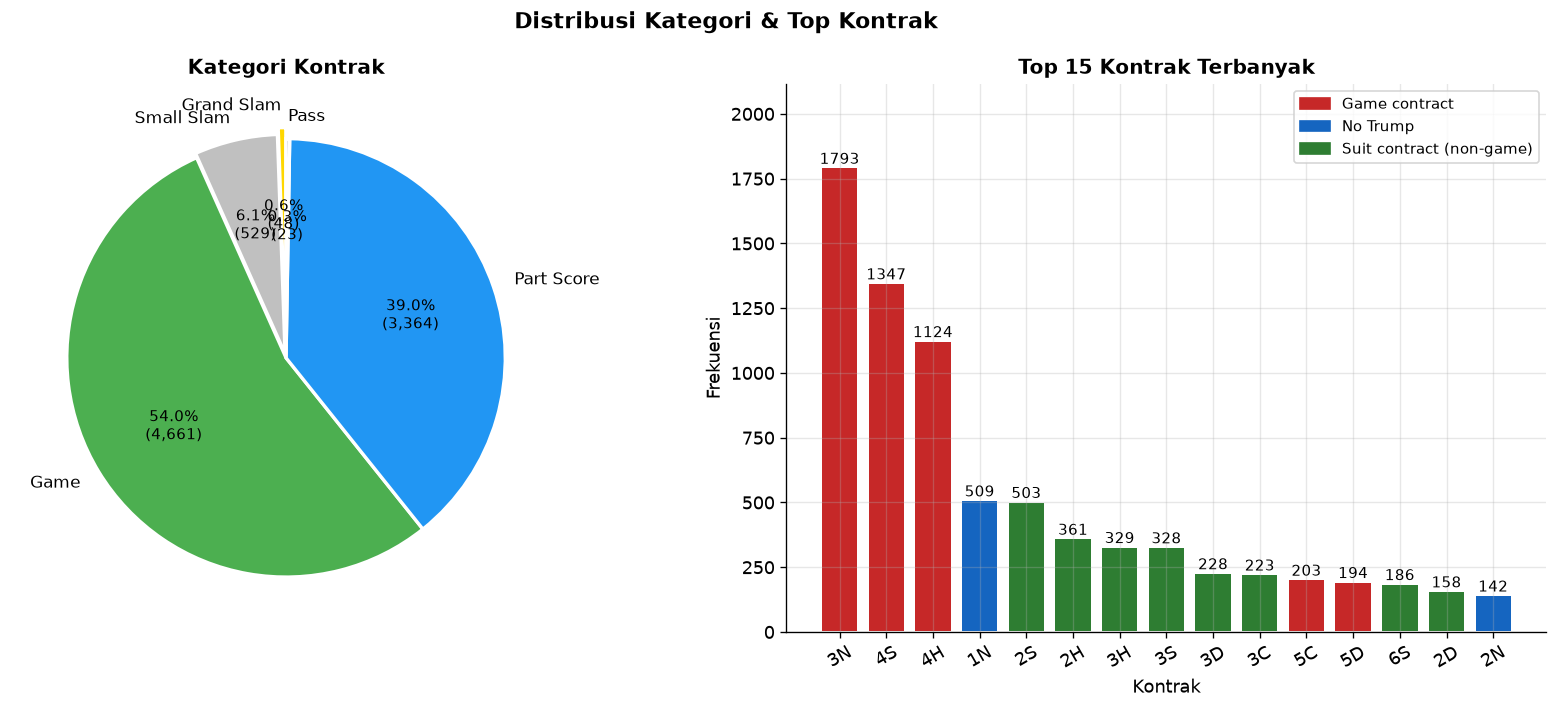

In [9]:
from src.features import get_contract_category, get_contract_base

cat_order  = ['GrandSlam', 'SmallSlam', 'Game', 'Partscore', 'Pass']
cat_labels = ['Grand Slam', 'Small Slam', 'Game', 'Part Score', 'Pass']
cat_cnt    = Counter(get_contract_category(b) for b in boards)
cat_vals   = [cat_cnt.get(c, 0) for c in cat_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart kategori
ax = axes[0]
pie_colors = ['#FFD700', '#C0C0C0', '#4CAF50', '#2196F3', '#9E9E9E']
explode    = [0.05, 0.02, 0, 0, 0]
wedges, texts, autotexts = ax.pie(
    cat_vals, labels=cat_labels, colors=pie_colors,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*sum(cat_vals)/100)):,})',
    startangle=90, explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10},
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Kategori Kontrak', fontweight='bold', fontsize=12)

# Bar chart top 15 kontrak
ax = axes[1]
contract_cnt = Counter(get_contract_base(b) for b in boards if b.contract_level)
top15        = contract_cnt.most_common(15)
clabels, cvals = zip(*top15)
game_set = {'3N', '4S', '4H', '5D', '5C'}
ccols = ['#C62828' if l in game_set else
         '#1565C0' if any(l.endswith(s) for s in ('N',)) else
         '#2E7D32' for l in clabels]
bars = ax.bar(clabels, cvals, color=ccols, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', fontsize=9)
ax.set_title('Top 15 Kontrak Terbanyak', fontweight='bold', fontsize=12)
ax.set_xlabel('Kontrak')
ax.set_ylabel('Frekuensi')
ax.set_ylim(0, max(cvals) * 1.18)
ax.tick_params(axis='x', rotation=30)

from matplotlib.patches import Patch
legend_el = [
    Patch(color='#C62828', label='Game contract'),
    Patch(color='#1565C0', label='No Trump'),
    Patch(color='#2E7D32', label='Suit contract (non-game)'),
]
ax.legend(handles=legend_el, fontsize=9)

plt.suptitle('Distribusi Kategori & Top Kontrak', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb01_contract_distribution.png', bbox_inches='tight')
plt.show()

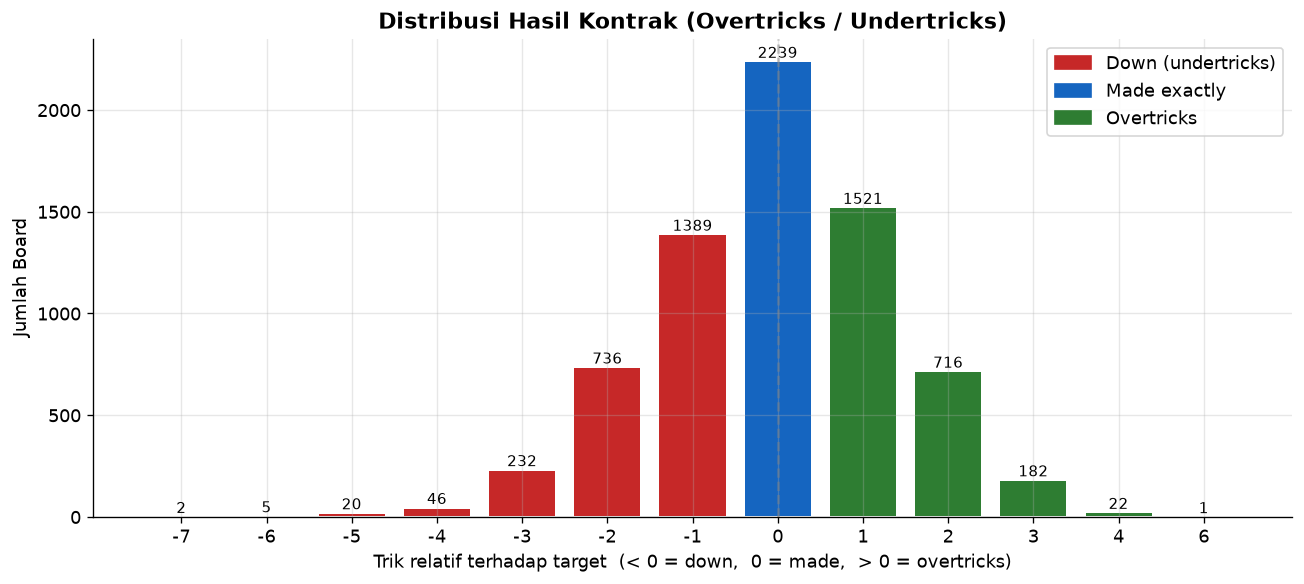

Kontrak made (>=0) : 4,681  (65.8%)
Kontrak down (<0)  : 2,430  (34.2%)


In [10]:
# Distribusi hasil (overtricks / undertricks)
results = [b.result for b in boards if b.result is not None]
result_cnt = Counter(results)
rkeys = sorted(result_cnt)
rvals = [result_cnt[k] for k in rkeys]

fig, ax = plt.subplots(figsize=(11, 5))
rcols = ['#C62828' if k < 0 else '#1565C0' if k == 0 else '#2E7D32' for k in rkeys]
bars = ax.bar([str(k) for k in rkeys], rvals, color=rcols, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', fontsize=9)

ax.axvline(x=rkeys.index(0), color='gray', linestyle='--', alpha=0.5, label='Made exactly (=)')
ax.set_title('Distribusi Hasil Kontrak (Overtricks / Undertricks)', fontweight='bold')
ax.set_xlabel('Trik relatif terhadap target  (< 0 = down,  0 = made,  > 0 = overtricks)')
ax.set_ylabel('Jumlah Board')

from matplotlib.patches import Patch
legend_el = [
    Patch(color='#C62828', label='Down (undertricks)'),
    Patch(color='#1565C0', label='Made exactly'),
    Patch(color='#2E7D32', label='Overtricks'),
]
ax.legend(handles=legend_el)
plt.tight_layout()
plt.savefig(OUT / 'nb01_result_distribution.png', bbox_inches='tight')
plt.show()

made    = sum(v for k, v in result_cnt.items() if k >= 0)
down    = sum(v for k, v in result_cnt.items() if k < 0)
print(f'Kontrak made (>=0) : {made:,}  ({made/len(results)*100:.1f}%)')
print(f'Kontrak down (<0)  : {down:,}  ({down/len(results)*100:.1f}%)')

---
## Ringkasan Notebook 1

| Item | Nilai |
|------|-------|
| File LIN | 411 |
| Total board | 8.625 |
| Board dengan kontrak | 8.602 (99,7%) |
| Board tangan lengkap | 8.614 (99,9%) |
| Distribusi vulnerability | Seimbang (~2.100–2.200 per kategori) |
| Distribusi dealer | Seimbang (~2.100–2.200 per seat) |
| Kontrak terbanyak | 3N (No Trump), 4S, 4H |
| Kategori dominan | Game (54%) & Part Score (39%) |

**Lanjut ke:** `02_eda_features.ipynb` → EDA & Feature Engineering